# Chapitre 2 — PyTorch pour les réseaux de neurones

*De la convolution brute à un petit CNN entraîné sur CIFAR-10.*

**🎯 Objectif :** maîtriser les briques de base de PyTorch (tenseurs, autograd, `nn.Module`, `Conv2d`, boucle d'entraînement) en entraînant un petit CNN puis un ResNet-18 sur CIFAR-10 — le socle pour lire le code de GMIC (ch6/ch7).
**⏱ Durée :** ~2–5 min sur GPU (télécharge CIFAR-10 ~170 Mo dans `data/in/cifar10`).

Introduction **autonome** à PyTorch : aucune classe spécifique à GMIC. À la fin tu sauras :

- manipuler des tenseurs et l'auto-différentiation,
- écrire un `nn.Module` et faire passer des données dedans,
- comprendre ce que fait une `Conv2d` (filtre, stride, padding),
- entraîner un petit CNN sur CIFAR-10 avec une boucle forward / backward,
- comparer un petit CNN maison avec un ResNet-18 standard, entraîné à la bonne résolution.

C'est le préquel naturel des chapitres GMIC (ch6 architecture, ch7 fine-tuning). Le notebook
**télécharge CIFAR-10** (~170 Mo, automatique) et entraîne deux réseaux : prévois un **GPU**
(disponible dans le conteneur du cours) pour que ça tourne en ~1–2 min.

> Les organigrammes sont dessinés en **matplotlib** (sortie de cellule de code) plutôt qu'en
> Mermaid : ils s'affichent ainsi partout. Le helper `flowchart()` vient de `course_utils.py`.

In [1]:
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, Subset, DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from course_utils import flowchart, data_in, pick_device, dataloader_kwargs, describe_env

plt.rcParams["figure.dpi"] = 110
torch.manual_seed(0)
np.random.seed(0)
torch.backends.cudnn.benchmark = True   # auto-tune cuDNN pour tailles d'entrée fixes

# Pas de warnings.filterwarnings("ignore") ici : un avertissement torch/pandas signale souvent
# une vraie dérive d'API. Si un warning précis devient bruyant, filtre-le NOMMÉMENT
# (warnings.filterwarnings("ignore", category=..., message=...)) plutôt que tout masquer.

DEVICE = pick_device(verbose=False)
describe_env()

=== Environnement détecté ===
OS                 : Linux (x86_64)
PyTorch            : 2.4.1+cu121
Device             : cuda
  GPU              : NVIDIA L40S
CPU cœurs          : 8
/dev/shm libre     : 47.15 Go
DataLoader workers : 4


# Partie I — Un tenseur, c'est un tableau avec des super-pouvoirs

Un **tenseur** PyTorch ressemble à un `np.array`, mais il sait :

1. tourner sur GPU (`.to("cuda")`) ;
2. enregistrer ses opérations pour calculer automatiquement les dérivées via `.backward()` —
   c'est l'**autograd**, le cœur de l'entraînement.

In [2]:
a = torch.tensor([[1., 2.], [3., 4.]])
b = torch.tensor([[0., 1.], [1., 0.]])
print("a + b =\n", a + b)
print("a @ b =\n", a @ b)        # produit matriciel
print("a.shape =", a.shape, " | dtype =", a.dtype)

a + b =
 tensor([[1., 3.],
        [4., 4.]])
a @ b =
 tensor([[2., 1.],
        [4., 3.]])
a.shape = torch.Size([2, 2])  | dtype = torch.float32


## Autograd en une image

On définit `y = x² + 3x + 2`, on demande à PyTorch de tracer les gradients, et on appelle
`.backward()`. La dérivée analytique est `dy/dx = 2x + 3`. En `x = 4` on attend donc `11`.

### Ce que PyTorch fabrique pendant le forward

Quand tu écris `y = x**2 + 3*x + 2`, PyTorch ne se contente pas de calculer un nombre : pour
chaque opération, il enregistre aussi *qui* étaient les entrées et *comment* remonter la
dérivée. Résultat : un **graphe de calcul** orienté, où `x` est la racine (une **feuille** :
tu l'as créé à la main) et `y` est la sortie (un **nœud intermédiaire**, fabriqué par PyTorch).
Le diagramme ci-dessous montre la passe avant (flèches pleines) et le résultat de la passe
arrière (chain rule).

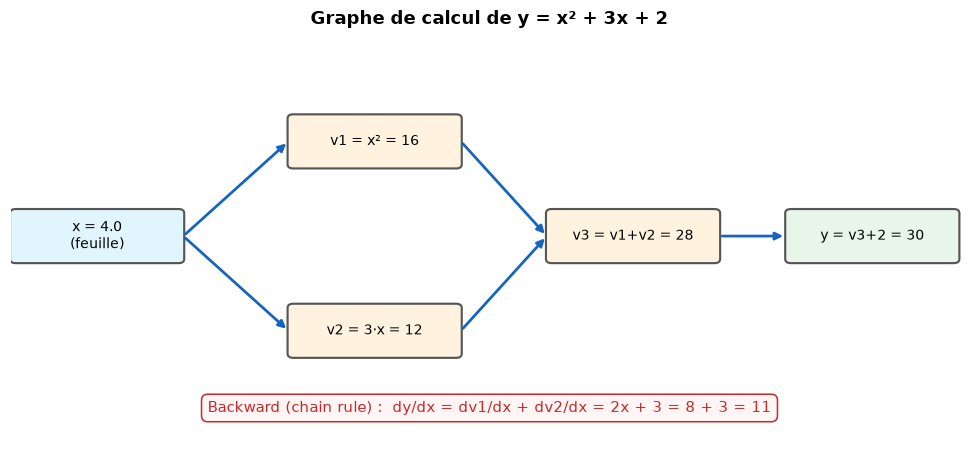

In [3]:
# Graphe de calcul de y = x² + 3x + 2 en x = 4 (forward plein -> backward résumé)
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.set_xlim(0, 10); ax.set_ylim(0, 6); ax.axis("off")

nodes = {
    "x":  (0.9, 3.0, "x = 4.0\n(feuille)",  "#e1f5fe"),
    "v1": (3.8, 4.4, "v1 = x² = 16",         "#fff3e0"),
    "v2": (3.8, 1.6, "v2 = 3·x = 12",        "#fff3e0"),
    "v3": (6.5, 3.0, "v3 = v1+v2 = 28",      "#fff3e0"),
    "y":  (9.0, 3.0, "y = v3+2 = 30",        "#e8f5e9"),
}
pos = {}
for name, (x, y, label, color) in nodes.items():
    ax.add_patch(FancyBboxPatch((x-0.85, y-0.34), 1.7, 0.68, boxstyle="round,pad=0.06",
                 facecolor=color, edgecolor="#555", linewidth=1.4))
    ax.text(x, y, label, ha="center", va="center", fontsize=9)
    pos[name] = (x, y)

def fwd(a, b):
    (x0, y0), (x1, y1) = pos[a], pos[b]
    ax.annotate("", xy=(x1-0.9, y1), xytext=(x0+0.9, y0),
                arrowprops=dict(arrowstyle="-|>", color="#1565c0", lw=1.8))

for a, b in [("x","v1"), ("x","v2"), ("v1","v3"), ("v2","v3"), ("v3","y")]:
    fwd(a, b)

ax.text(5, 0.4, "Backward (chain rule) :  dy/dx = dv1/dx + dv2/dx = 2x + 3 = 8 + 3 = 11",
        ha="center", fontsize=10, color="#c62828",
        bbox=dict(boxstyle="round,pad=0.4", fc="#fff5f5", ec="#c62828"))
ax.set_title("Graphe de calcul de y = x² + 3x + 2", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

**Pourquoi `x.grad` et pas `y.grad` ?** PyTorch ne stocke par défaut le gradient que sur les
**feuilles** (tenseurs créés par toi avec `requires_grad=True`). `y` est un intermédiaire : son
`.grad` reste `None`. On peut forcer avec `y.retain_grad()`, mais en pratique on n'a besoin que
des gradients des paramètres (les poids), qui sont justement des feuilles.

**Pourquoi un `.backward()` sur un scalaire ?** PyTorch ne sait dériver que des scalaires par
rapport à des tenseurs. Si `y` était un vecteur, il faudrait préciser par rapport à quelle
combinaison linéaire dériver (`grad_tensors=...`). D'où le `loss.backward()` toujours sur une
loss réduite à un seul nombre.

### Cycle de vie du graphe de calcul

Le graphe n'est pas gratuit : pour un gros modèle il peut peser plusieurs Go de RAM GPU.
PyTorch **le détruit par défaut après chaque `.backward()`** pour libérer la mémoire — un second
`.backward()` sur le même `y` plantera, sauf si `retain_graph=True`.

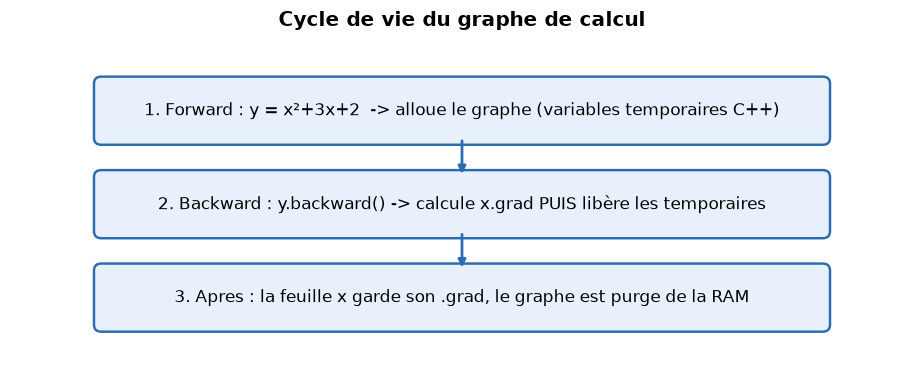

In [4]:
flowchart([
    "1. Forward : y = x²+3x+2  -> alloue le graphe (variables temporaires C++)",
    "2. Backward : y.backward() -> calcule x.grad PUIS libère les temporaires",
    "3. Apres : la feuille x garde son .grad, le graphe est purge de la RAM",
], title="Cycle de vie du graphe de calcul")

In [5]:
x = torch.tensor(4.0, requires_grad=True)
y = x ** 2 + 3 * x + 2
print("Avant backward :", x.grad)              # None — graphe créé, pas encore de gradient
y.backward()
print(f"y = {y.item()}")                        # 30.0 (valeur forward)
print(f"y.grad              : {y.grad}")        # None — y n'est pas une feuille
print(f"x.grad              : {x.grad.item()}") # 11.0 — gradient de la feuille
print(f"2x + 3 (analytique) : {2*4 + 3}")

Avant backward : None
y = 30.0
y.grad              : None
x.grad              : 11.0
2x + 3 (analytique) : 11


/tmp/ipykernel_646/3963333047.py:6: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at aten/src/ATen/core/TensorBody.h:489.)
  print(f"y.grad              : {y.grad}")        # None — y n'est pas une feuille


### Les gradients s'**accumulent**

Piège classique : `.grad` ne s'écrase pas, il s'**additionne** à chaque `.backward()`. Sans
remise à zéro, on obtient la somme des dérivées. D'où l'obligation d'appeler
`optimizer.zero_grad()` (ou `x.grad.zero_()`) au début de chaque itération.

In [6]:
x = torch.tensor(4.0, requires_grad=True)

y1 = x ** 2 + 3 * x + 2          # dy1/dx = 2x + 3 = 11
y1.backward()
print(f"après y1.backward : x.grad = {x.grad.item()}")   # 11

y2 = x ** 2                       # dy2/dx = 2x      = 8
y2.backward()
print(f"après y2.backward : x.grad = {x.grad.item()}")   # 19 = 11 + 8 (accumulation)

x.grad.zero_()                    # on remet le compteur à zéro
y3 = 5 * x
y3.backward()
print(f"après zero_() + y3 : x.grad = {x.grad.item()}")  # 5

après y1.backward : x.grad = 11.0
après y2.backward : x.grad = 19.0
après zero_() + y3 : x.grad = 5.0


# Partie II — Mon premier `nn.Module`

Un **module** PyTorch, c'est : (1) une classe qui hérite de `nn.Module` ; (2) un `__init__` qui
déclare les **couches à poids apprenables** ; (3) une méthode `forward(x)` qui décrit le calcul.
Construisons le plus petit réseau possible : une régression linéaire `y = w·x + b`.

In [7]:
class MiniLinear(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(in_features=1, out_features=1)

    def forward(self, x):
        return self.linear(x)

net = MiniLinear()
print(net)
print("Paramètres :", list(net.parameters()))

MiniLinear(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)
Paramètres : [Parameter containing:
tensor([[-0.0075]], requires_grad=True), Parameter containing:
tensor([0.5364], requires_grad=True)]


## Entraîner `MiniLinear` à apprendre `y = 2x + 1`

On assemble le module avec les trois autres briques : **des données**, **une loss** (à quel
point on se trompe), **un optimiseur** (qui met à jour les poids depuis le gradient). On fabrique
20 points bruités sur la droite `y = 2x + 1` et on demande au réseau de retrouver les coefficients.

In [8]:
# 1. Données synthétiques : y_true = 2x + 1 + bruit gaussien
torch.manual_seed(0)
X = torch.linspace(-3, 3, 20).unsqueeze(1)        # shape (20, 1)
y_true = 2 * X + 1 + 0.3 * torch.randn_like(X)    # bruit d'écart-type 0.3

# 2. Le réseau, la loss et l'optimiseur
net = MiniLinear()
loss_fn = nn.MSELoss()                            # erreur quadratique moyenne
optimizer = torch.optim.SGD(net.parameters(), lr=0.05)

# 3. La boucle — les 5 lignes canoniques de PyTorch
losses = []
for step in range(200):
    y_pred = net(X)                               # (1) forward
    loss = loss_fn(y_pred, y_true)                # (2) comparer à la vérité
    optimizer.zero_grad()                         # (3) reset gradients
    loss.backward()                               # (4) rétro-propagation
    optimizer.step()                              # (5) mise à jour w et b
    losses.append(loss.item())
    if step % 40 == 0:
        print(f"step {step:3d}  loss = {loss.item():.4f}")

w = net.linear.weight.item(); b = net.linear.bias.item()
print(f"\nAppris : y ≈ {w:.3f} * x + {b:.3f}")
print(f"Vérité : y = 2.000 * x + 1.000")

step   0  loss = 23.9486
step  40  loss = 0.0667
step  80  loss = 0.0667
step 120  loss = 0.0667
step 160  loss = 0.0667

Appris : y ≈ 2.097 * x + 1.104
Vérité : y = 2.000 * x + 1.000


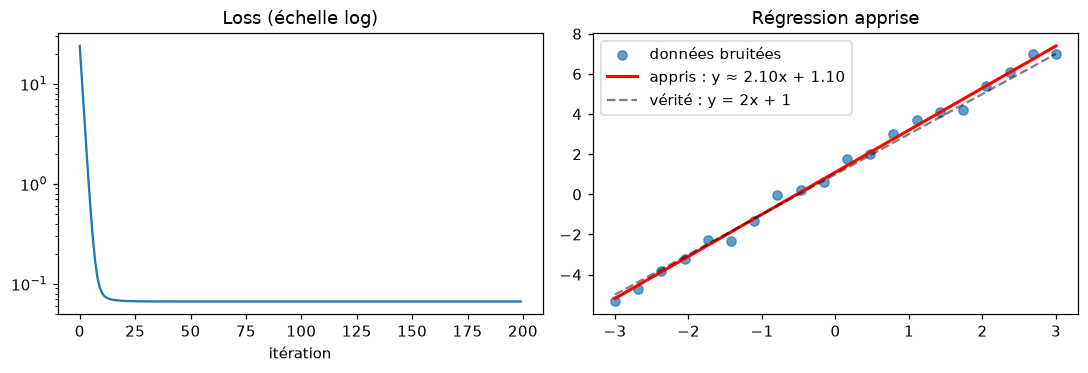

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(losses); ax[0].set_yscale("log")
ax[0].set_title("Loss (échelle log)"); ax[0].set_xlabel("itération")

ax[1].scatter(X.numpy(), y_true.numpy(), label="données bruitées", alpha=0.7)
x_line = torch.linspace(-3, 3, 100).unsqueeze(1)
with torch.no_grad():
    y_line = net(x_line)
ax[1].plot(x_line.numpy(), y_line.numpy(), "r-", lw=2, label=f"appris : y ≈ {w:.2f}x + {b:.2f}")
ax[1].plot(x_line.numpy(), (2 * x_line + 1).numpy(), "k--", alpha=0.5, label="vérité : y = 2x + 1")
ax[1].legend(); ax[1].set_title("Régression apprise")
plt.tight_layout(); plt.show()

Ce micro-entraînement est **la même boucle** qu'on utilisera pour CIFAR-10 (Partie VI), pour
ResNet-18 (Partie VIII) et pour le fine-tuning sur mammographies (ch4, ch7). Seuls changent
l'architecture, la loss et la source de données. Le squelette **forward → loss → zero_grad →
backward → step** est invariant.

# Partie III — `nn.Conv2d`, la brique des CNN

Pour classer une image, on ne traite pas chaque pixel comme une feature indépendante : il y en a
trop, et surtout l'information est **locale** (un œil, une roue, une tumeur). La convolution
résout ça. Une `Conv2d(in_channels=3, out_channels=8, kernel_size=3)` fait glisser **8 filtres**
3×3 sur l'entrée (3 canaux RGB) et produit **8 cartes d'activation**.

## Quatre filtres classiques sur une vraie image

On prend une image CIFAR-10 et on lui applique quatre **filtres codés à la main** :
**Sobel X** (bords verticaux), **Sobel Y** (bords horizontaux), **Laplacien** (tous les contours),
**Moyenneur 3×3** (flou). Idiomes PyTorch utilisés : les méthodes en `_` (`copy_`) sont
**in-place** ; `.view(1,1,3,3)` reshape sans copie vers `(out, in, H, W)` ; `with torch.no_grad():`
désactive le traçage (obligatoire pour écrire des poids in-place) ; `bias=False` évite un décalage
appris ; `.detach()` casse le lien avec le graphe.

Files already downloaded and verified


[W904 09:53:28.456771273 NNPACK.cpp:61] Could not initialize NNPACK! Reason: Unsupported hardware.


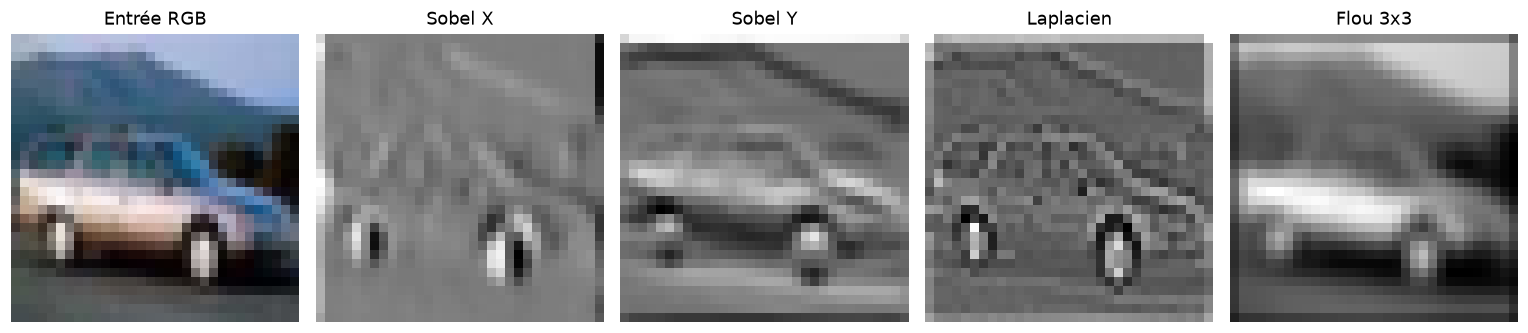

In [10]:
CIFAR_ROOT = data_in("cifar10")
_demo_ds = datasets.CIFAR10(root=CIFAR_ROOT, train=True,
                            transform=transforms.ToTensor(), download=True)

# Une image de voiture (classe 1) pour avoir des bords nets
for _img, _lbl in _demo_ds:
    if _lbl == 1:
        img_rgb = _img            # (3, 32, 32) en [0, 1]
        break
img_gray = img_rgb.mean(0, keepdim=True).unsqueeze(0)   # (1, 1, 32, 32)

filters = {
    "Sobel X":   torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=torch.float32),
    "Sobel Y":   torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=torch.float32),
    "Laplacien": torch.tensor([[0, -1, 0], [-1, 4, -1], [0, -1, 0]], dtype=torch.float32),
    "Flou 3x3":  torch.ones(3, 3) / 9.0,
}

fig, axes = plt.subplots(1, 5, figsize=(14, 3))
axes[0].imshow(img_rgb.permute(1, 2, 0)); axes[0].set_title("Entrée RGB"); axes[0].axis("off")
for ax, (name, k) in zip(axes[1:], filters.items()):
    conv = nn.Conv2d(1, 1, kernel_size=3, padding=1, bias=False)
    with torch.no_grad():
        conv.weight.copy_(k.view(1, 1, 3, 3))
    feat = conv(img_gray)[0, 0].detach()
    ax.imshow(feat, cmap="gray"); ax.set_title(name); ax.axis("off")
plt.tight_layout(); plt.show()

**Clé pédagogique** : dans un vrai CNN, ces coefficients 3×3 ne sont pas codés à la main — ils
sont **appris** par descente de gradient. Ci-dessous, `nn.Conv2d(3, 8, 3)` crée 8 filtres
indépendants → 8 cartes d'activation. Avant entraînement, ils sont aléatoires (bruit structuré).

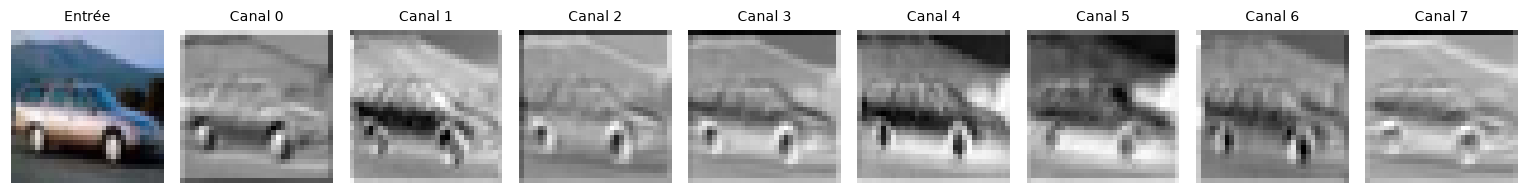

In [11]:
torch.manual_seed(0)
conv = nn.Conv2d(3, 8, kernel_size=3, padding=1, bias=False)
with torch.no_grad():
    feat = conv(img_rgb.unsqueeze(0))    # (1, 8, 32, 32)

fig, axes = plt.subplots(1, 9, figsize=(14, 2))
axes[0].imshow(img_rgb.permute(1, 2, 0)); axes[0].set_title("Entrée", fontsize=9); axes[0].axis("off")
for i in range(8):
    axes[i + 1].imshow(feat[0, i].detach(), cmap="gray")
    axes[i + 1].set_title(f"Canal {i}", fontsize=9); axes[i + 1].axis("off")
plt.tight_layout(); plt.show()

## Effet des hyperparamètres

| Paramètre | Rôle | Effet sur la shape |
|:---|:---|:---|
| `kernel_size` | taille du filtre | plus grand = champ réceptif plus large |
| `stride` | pas de déplacement | stride 2 divise H et W par ~2 |
| `padding` | zéros ajoutés aux bords | préserve la shape d'entrée |
| `out_channels` | nombre de filtres | dimension du canal en sortie |

In [12]:
x = torch.randn(1, 3, 32, 32)       # batch 1, 3 canaux, 32x32
for (k, s, p) in [(3, 1, 1), (3, 2, 1), (5, 1, 0), (7, 2, 3)]:
    c = nn.Conv2d(3, 8, kernel_size=k, stride=s, padding=p)
    out = c(x)
    print(f"kernel={k} stride={s} padding={p}  ->  in {tuple(x.shape)}  out {tuple(out.shape)}")

kernel=3 stride=1 padding=1  ->  in (1, 3, 32, 32)  out (1, 8, 32, 32)
kernel=3 stride=2 padding=1  ->  in (1, 3, 32, 32)  out (1, 8, 16, 16)
kernel=5 stride=1 padding=0  ->  in (1, 3, 32, 32)  out (1, 8, 28, 28)
kernel=7 stride=2 padding=3  ->  in (1, 3, 32, 32)  out (1, 8, 16, 16)


# Partie IV — CIFAR-10 et le pipeline de données

CIFAR-10 = 60 000 images 32×32 couleur, 10 classes. Avant de la donner au réseau, on passe par
trois briques que PyTorch impose pour **tout** entraînement :

| Brique | Rôle | Entrée | Sortie |
|:---|:---|:---|:---|
| `transforms` | **transformer** une image | `PIL.Image` / tenseur | tenseur prêt pour le réseau |
| `Dataset` | **exposer** les échantillons un par un | un index `i` | `(x_i, y_i)` |
| `DataLoader` | **batcher + paralléliser** | un `Dataset` | une séquence de batches |

### `transforms` — le pipeline par image
- `ToTensor()` : `PIL.Image` (uint8 0–255) → `float32` dans [0,1], convention **(C, H, W)**.
- `Normalize(mean, std)` : `(x - mean) / std`. Ici `0.5/0.5` mappe [0,1] → [-1,1]. Un réseau
  converge plus vite avec des entrées centrées/échelle ~1. Pour un modèle pré-entraîné ImageNet,
  on utilise les stats `mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]`.

### `Dataset` — l'interface minimale
Deux questions : `__len__` (combien ?) et `__getitem__(i)` (donne l'échantillon i). C'est tout.

In [13]:
# 🎯 Objectif de la cellule : montrer l'interface MINIMALE d'un Dataset PyTorch.
class MyDataset(Dataset):
    """Dataset jouet : expose des paires (x, y) déjà en mémoire.

    Un Dataset PyTorch doit seulement répondre à deux questions :
      - __len__      : combien d'échantillons ?
      - __getitem__  : donne-moi le i-ème, sous la forme (x_i, y_i).
    """
    def __init__(self, xs, ys):
        self.xs, self.ys = xs, ys            # deux listes de même longueur
    def __len__(self):
        return len(self.xs)
    def __getitem__(self, i):
        return self.xs[i], self.ys[i]        # PyTorch ne demande rien de plus

tiny = MyDataset([torch.randn(3) for _ in range(4)], [0, 1, 1, 0])
print("len :", len(tiny))
print("item 2 :", tiny[2])

len : 4
item 2 : (tensor([-0.0282, -0.0524, -1.0896]), 1)


### `DataLoader` — le gestionnaire de batches
Il résout d'un coup : (1) **shuffle** des indices à chaque epoch ; (2) **batching** (empile
`batch_size` échantillons via `torch.stack`) ; (3) **parallélisation** avec `num_workers=N`
(sous-processus qui pré-calculent les batches — gain majeur quand `__getitem__` est lourd) ;
(4) **`pin_memory=True`** (transfert GPU en une DMA, gratuit sur CUDA). Ensuite on écrit juste
`for x, y in loader: ...`.

Files already downloaded and verified
Files already downloaded and verified
Classes : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train subset : 10000 images  |  Test subset : 2000 images
Shape d'un batch : torch.Size([128, 3, 32, 32])  (N, C, H, W)


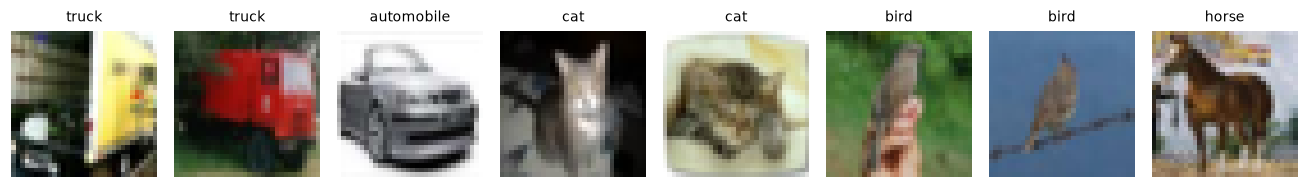

In [14]:
transform = transforms.Compose([
    transforms.ToTensor(),                                  # [0,255] -> [0,1], (3,32,32)
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)), # -> [-1, 1]
])

# CIFAR_ROOT est déjà défini en Partie III (une seule source de vérité pour le chemin).
train_full = datasets.CIFAR10(root=CIFAR_ROOT, train=True,  transform=transform, download=True)
test_full  = datasets.CIFAR10(root=CIFAR_ROOT, train=False, transform=transform, download=True)

# Sous-échantillons pour garder le notebook rapide
train_ds = Subset(train_full, range(10_000))
test_ds  = Subset(test_full,  range(2_000))

# dataloader_kwargs() choisit num_workers / pin_memory / etc. selon la machine (voir course_utils).
train_loader = DataLoader(train_ds, **dataloader_kwargs(batch_size=128, shuffle=True))
test_loader  = DataLoader(test_ds,  **dataloader_kwargs(batch_size=256, shuffle=False))

classes = train_full.classes
print("Classes :", classes)
print(f"Train subset : {len(train_ds)} images  |  Test subset : {len(test_ds)} images")

imgs, labels = next(iter(train_loader))
print(f"Shape d'un batch : {imgs.shape}  (N, C, H, W)")
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
    img = imgs[i].permute(1, 2, 0).numpy() * 0.5 + 0.5   # dé-normalisation pour affichage
    ax.imshow(img); ax.set_title(classes[labels[i]], fontsize=9); ax.axis("off")
plt.tight_layout(); plt.show()

Note la dé-normalisation `* 0.5 + 0.5` pour l'affichage : `matplotlib` veut des pixels dans
[0, 1] alors que `Normalize` nous a mis dans [-1, 1]. Le pipeline d'affichage est l'inverse du
pipeline d'entraînement.

# Partie V — Architecture d'un petit CNN

CNN simple à **deux** étages convolutifs + une tête fully-connected, sur le schéma canonique :
`Conv → BatchNorm → ReLU → MaxPool` (×N), puis `Flatten → Linear → ReLU → Linear(10)`.

In [15]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        # Bloc 1 : 3->32 canaux, pool -> 16x16
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        # Bloc 2 : 32->64 canaux, pool -> 8x8
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)
        # Tête
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))   # (N, 32, 16, 16)
        x = self.pool(F.relu(self.bn2(self.conv2(x))))   # (N, 64,  8,  8)
        x = x.view(x.size(0), -1)                         # flatten (N, 4096)
        x = self.dropout(F.relu(self.fc1(x)))             # (N, 128)
        return self.fc2(x)                                # (N, 10) logits

model = SmallCNN().to(DEVICE)
print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f"\nParamètres totaux : {n_params:,}  ({n_params/1e6:.2f} M)")

SmallCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

Paramètres totaux : 545,290  (0.55 M)


# Partie VI — La boucle d'entraînement

Les lignes magiques de **tout** entraînement PyTorch : `pred = model(x)` (forward) →
`loss = criterion(pred, y)` → `loss.backward()` → `optimizer.step()` → `optimizer.zero_grad()`.
Emballées dans deux boucles : sur les **époques** et sur les **batches**.

`criterion` n'est pas un mot-clé, juste une convention pour « la fonction de loss ».
`nn.CrossEntropyLoss` attend les **logits** (pas les probabilités) : elle applique
`LogSoftmax + NLLLoss` en interne — d'où le `forward` de `SmallCNN` qui renvoie `fc2(x)` sans
activation finale. Cas voisins : binaire → `BCEWithLogitsLoss` ; régression → `MSELoss`.

In [16]:
# 🎯 Objectif de la cellule : définir les 2 fonctions réutilisées partout (entraîner une
#    époque / évaluer), puis lancer la boucle sur EPOCHS époques en suivant les métriques.
def train_one_epoch(model, loader, optimizer, criterion, device, desc='train'):
    """Entraîne le modèle sur UNE époque. Renvoie (loss moyenne, accuracy).

    Cœur de PyTorch : pour chaque batch -> forward -> loss -> zero_grad ->
    backward -> step. `model.train()` active dropout/BatchNorm en mode entraînement.
    La barre tqdm (leave=False) montre l'avancement des batches dans l'époque.
    """
    model.train()
    total, correct, running_loss = 0, 0, 0.0
    for x, y in tqdm(loader, desc=desc, leave=False):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
        correct += (pred.argmax(1) == y).sum().item()
        total += x.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Évalue le modèle SANS calculer de gradients (@torch.no_grad + model.eval()).

    Renvoie (loss moyenne, accuracy). `eval()` fige dropout/BatchNorm pour des
    prédictions déterministes.
    """
    model.eval()
    total, correct, running_loss = 0, 0, 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x)
        running_loss += criterion(pred, y).item() * x.size(0)
        correct += (pred.argmax(1) == y).sum().item()
        total += x.size(0)
    return running_loss / total, correct / total


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
EPOCHS = 15   # assez pour sortir du hasard (10 %) et atteindre ~60-70 % (cf Partie VI), sans alourdir le notebook (~1-2 min/GPU)
t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE,
                                      desc=f'SmallCNN epoch {epoch}/{EPOCHS}')
    vl_loss, vl_acc = evaluate(model, test_loader, criterion, DEVICE)
    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["val_loss"].append(vl_loss);  history["val_acc"].append(vl_acc)
    print(f"Epoch {epoch}/{EPOCHS}  "
          f"train loss={tr_loss:.3f} acc={tr_acc*100:.1f}%   "
          f"val loss={vl_loss:.3f} acc={vl_acc*100:.1f}%")
smallcnn_time = time.time() - t0
print(f"\n⏱ Entraînement SmallCNN ({EPOCHS} époques) : {smallcnn_time:.1f} s")

SmallCNN epoch 1/15:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 1/15  train loss=1.815 acc=33.7%   val loss=1.491 acc=47.3%


SmallCNN epoch 2/15:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 2/15  train loss=1.476 acc=45.8%   val loss=1.397 acc=51.2%


SmallCNN epoch 3/15:   0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 13/15  train loss=0.718 acc=73.6%   val loss=1.075 acc=62.9%


SmallCNN epoch 14/15:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 14/15  train loss=0.711 acc=73.9%   val loss=1.037 acc=63.9%


SmallCNN epoch 15/15:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 15/15  train loss=0.662 acc=75.8%   val loss=1.038 acc=65.5%

⏱ Entraînement SmallCNN (15 époques) : 12.3 s


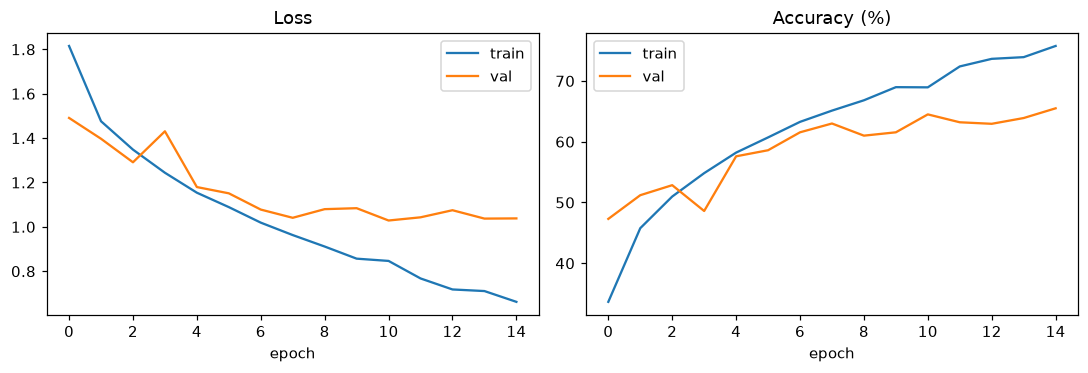

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(history["train_loss"], label="train"); ax[0].plot(history["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot([a*100 for a in history["train_acc"]], label="train")
ax[1].plot([a*100 for a in history["val_acc"]],   label="val")
ax[1].set_title("Accuracy (%)"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

Si tout va bien : loss qui descend, accuracy qui monte. Avec 10 000 images, on tourne autour
de **60-70 %** sur CIFAR-10 — loin de l'état de l'art (~99 %) mais largement au-dessus du
**hasard (10 %)** pour un réseau entraîné en moins d'une minute.

> **Pourquoi « hasard = 10 % » ?** CIFAR-10 a **10 classes équilibrées** → un classifieur
> aléatoire tombe juste 1 fois sur 10. Pour N classes équilibrées le baseline est 1/N ; pour du
> binaire, 50 %.

# Partie VII — Prédictions visualisées

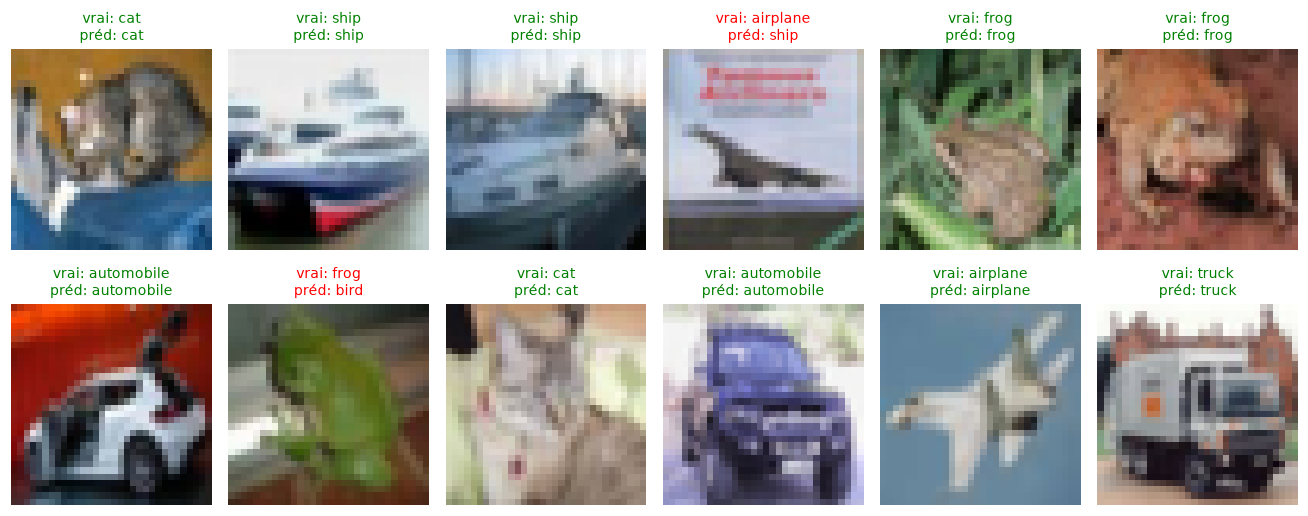

In [18]:
model.eval()
imgs, labels = next(iter(test_loader))
with torch.no_grad():
    preds = model(imgs.to(DEVICE)).argmax(1).cpu()

fig, axes = plt.subplots(2, 6, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    img = imgs[i].permute(1, 2, 0).numpy() * 0.5 + 0.5
    ok = preds[i].item() == labels[i].item()
    color = "green" if ok else "red"
    ax.imshow(img); ax.axis("off")
    ax.set_title(f"vrai: {classes[labels[i]]}\npréd: {classes[preds[i]]}",
                 fontsize=9, color=color)
plt.tight_layout(); plt.show()

## Les primitives à retenir

| Concept | Classe/fonction | Rôle |
|:---|:---|:---|
| Tenseur | `torch.tensor`, `.to(device)` | donnée de base |
| Dérivation | `.backward()`, `.grad` | autograd |
| Couche | `nn.Linear`, `nn.Conv2d`, `nn.BatchNorm2d` | poids apprenables |
| Module | `nn.Module` + `forward(x)` | composition |
| Non-linéarité | `F.relu`, `torch.sigmoid` | sans poids |
| Loss | `nn.CrossEntropyLoss`, `nn.MSELoss` | mesure d'écart |
| Optimiseur | `torch.optim.Adam`, `torch.optim.SGD` | descente de gradient |
| Données | `Dataset`, `DataLoader` | pipeline de batches |
| Régularisation | `nn.Dropout`, `nn.BatchNorm2d` | stabilité + généralisation |

Avec ces briques tu peux lire **n'importe quel** code PyTorch moderne, y compris GMIC (ch6).

Chapitre suivant → `03_preprocessing.ipynb`.